In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time


# DATASET

data = fetch_california_housing()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

X_all = df[data.feature_names].values
y     = df['target'].values

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

scaler_y  = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_s  = scaler_y.transform(y_test.reshape(-1,1)).flatten()


# HELPER FUNCTIONS

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient_descent(X, y, lr=0.01, iters=1000):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(iters):
        pred  = X @ theta
        grad  = (2/m) * X.T @ (pred - y)
        theta = theta - lr * grad
        losses.append(mse(y, pred))
    return theta, losses

def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y




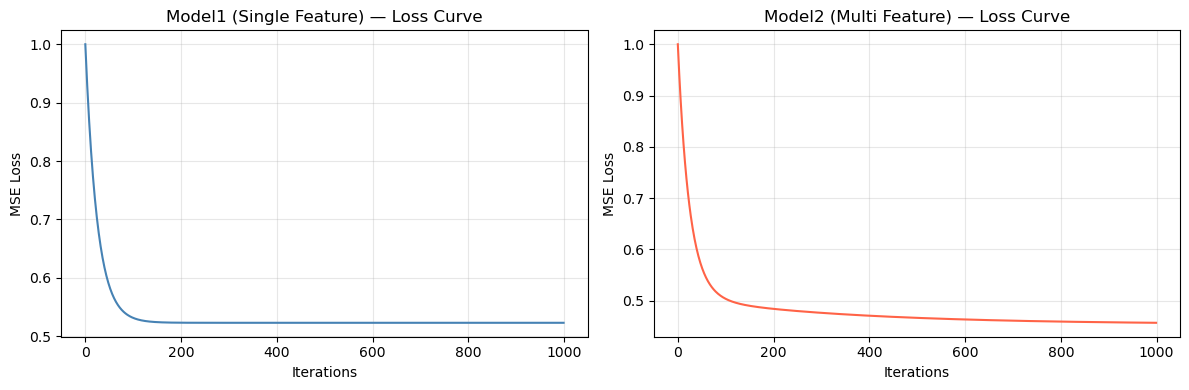

In [4]:
# MODEL 1 — Single Feature (MedInc)
feat1     = 'MedInc'
feat1_idx = data.feature_names.index(feat1)

scaler1  = StandardScaler()
X1_train = scaler1.fit_transform(X_train_full[:, [feat1_idx]])
X1_test  = scaler1.transform(X_test_full[:, [feat1_idx]])

X1_train_b = add_bias(X1_train)
X1_test_b  = add_bias(X1_test)

theta1, losses1 = gradient_descent(X1_train_b, y_train_s, lr=0.01, iters=1000)


# MODEL 2 — Multiple Features (6 features)

feats2 = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
idx2   = [data.feature_names.index(f) for f in feats2]

scaler2  = StandardScaler()
X2_train = scaler2.fit_transform(X_train_full[:, idx2])
X2_test  = scaler2.transform(X_test_full[:, idx2])

X2_train_b = add_bias(X2_train)
X2_test_b  = add_bias(X2_test)

theta2, losses2 = gradient_descent(X2_train_b, y_train_s, lr=0.01, iters=1000)


# PLOT 1 — Loss vs Iterations (Model1 and Model2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses1, color='steelblue', linewidth=1.5)
axes[0].set_title('Model1 (Single Feature) — Loss Curve')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses2, color='tomato', linewidth=1.5)
axes[1].set_title('Model2 (Multi Feature) — Loss Curve')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('MSE Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()




In [ ]:
# PLOT 2 — Final Regression Line on Data Points

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model1 — scatter + regression line
sample_idx = np.random.choice(len(X1_train), 100, replace=False)
x_pts  = X1_train[sample_idx, 0]
y_pts  = y_train_s[sample_idx]
x_line = np.linspace(x_pts.min(), x_pts.max(), 100)
y_line = theta1[0] + theta1[1] * x_line

axes[0].scatter(x_pts, y_pts, alpha=0.4, color='steelblue', s=20, label='Data points')
axes[0].plot(x_line, y_line, 'r-', linewidth=2.5, label='Regression line')
axes[0].set_title(f'Model1: {feat1} vs Target')
axes[0].set_xlabel(f'{feat1} (scaled)')
axes[0].set_ylabel('Target (scaled)')
axes[0].legend()

# Model2 — actual vs predicted
y2_pred = X2_train_b @ theta2
axes[1].scatter(y_train_s[:300], y2_pred[:300], alpha=0.4, color='tomato', s=20, label='Predictions')
axes[1].plot([y_train_s.min(), y_train_s.max()],
             [y_train_s.min(), y_train_s.max()], 'k--', linewidth=1.5, label='Perfect fit')
axes[1].set_title('Model2: Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].legend()

plt.tight_layout()
plt.savefig('regression_line.png', dpi=150)
plt.show()


# PLOT 3 — Contour Plot for Model1

t0_range = np.linspace(theta1[0] - 1.5, theta1[0] + 1.5, 100)
t1_range = np.linspace(theta1[1] - 1.5, theta1[1] + 1.5, 100)
T0, T1   = np.meshgrid(t0_range, t1_range)

Z = np.array([
    [mse(y_train_s, t0 + t1 * X1_train[:, 0]) for t0, t1 in zip(row0, row1)]
    for row0, row1 in zip(T0, T1)
])

# Record GD path from scratch
theta_path = [np.zeros(2)]
t = np.zeros(2)
for _ in range(200):
    pred = X1_train_b @ t
    grad = (2 / len(y_train_s)) * X1_train_b.T @ (pred - y_train_s)
    t    = t - 0.01 * grad
    theta_path.append(t.copy())
theta_path = np.array(theta_path)

plt.figure(figsize=(9, 7))
cf = plt.contourf(T0, T1, Z, levels=50, cmap='viridis')
plt.colorbar(cf, label='MSE Loss')
plt.contour(T0, T1, Z, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.plot(theta_path[:, 0], theta_path[:, 1], 'r.-', markersize=4, label='GD Path', linewidth=1)
plt.scatter([theta1[0]], [theta1[1]], color='yellow', s=150, zorder=5, marker='*', label='Converged θ')
plt.scatter([0], [0], color='white', s=80, zorder=5, label='Start (0,0)')
plt.title('Contour Plot — Loss w.r.t θ0 and θ1')
plt.xlabel('θ0 (bias)')
plt.ylabel('θ1 (slope)')
plt.legend()
plt.savefig('contour_plot.png', dpi=150)
plt.show()




In [ ]:
# PLOT 4 — Different Learning Rates

# Comment on learning rates:
# η=0.001 → too slow, loss barely decreases in 500 iterations
# η=0.005 → slow but steady convergence
# η=0.01  → good balance, converges smoothly  ← best here
# η=0.05  → fast initially but may overshoot and oscillate

learning_rates = [0.001, 0.005, 0.01, 0.05]
colors         = ['royalblue', 'green', 'orange', 'crimson']

plt.figure(figsize=(9, 5))
for lr, color in zip(learning_rates, colors):
    _, lr_losses = gradient_descent(X1_train_b, y_train_s, lr=lr, iters=500)
    plt.plot(lr_losses, color=color, label=f'η = {lr}', linewidth=1.5)

plt.title('Effect of Learning Rate on Convergence')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_rates.png', dpi=150)
plt.show()


# PART 2 — NORMAL EQUATION
# θ = (XᵀX)⁻¹ Xᵀy
print("\n" + "="*70)
print(f"{'Method':<25} {'Train Loss':>12} {'Test Loss':>12} {'Time(s)':>12}  Remarks")
print("="*70)

configs = [
    ('Model1 (1 feature)',  X1_train_b, X1_test_b, theta1),
    ('Model2 (6 features)', X2_train_b, X2_test_b, theta2),
]

for name, Xtr, Xte, th_gd in configs:

    # Gradient Descent
    t0 = time.time()
    th_gd_t, _ = gradient_descent(Xtr, y_train_s, lr=0.01, iters=1000)
    gd_time    = time.time() - t0
    gd_train   = mse(y_train_s, Xtr @ th_gd_t)
    gd_test    = mse(y_test_s,  Xte @ th_gd_t)

    # Normal Equation
    t0 = time.time()
    th_ne   = normal_equation(Xtr, y_train_s)
    ne_time = time.time() - t0
    ne_train = mse(y_train_s, Xtr @ th_ne)
    ne_test  = mse(y_test_s,  Xte @ th_ne)

    print(f"\n── {name} ──")
    print(f"{'GD':<25} {gd_train:>12.5f} {gd_test:>12.5f} {gd_time:>12.5f}  Iterative, scalable")
    print(f"{'Normal Equation':<25} {ne_train:>12.5f} {ne_test:>12.5f} {ne_time:>12.6f}  Exact closed-form")
    print(f"  GD θ[:3]  = {np.round(th_gd_t[:3], 4)}")
    print(f"  NE θ[:3]  = {np.round(th_ne[:3], 4)}")

print("\n" + "="*70)